In [1]:
!pip install gymnasium numpy pandas matplotlib requests stable-baselines3 torch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 42.0 MB/s eta 0:00:00


In [2]:
# soil_model.py
import numpy as np

class SoilModel:
    """
    3-layer bucket model of soil water dynamics.
    Layers: surface (0-10cm), root zone (10-30cm), deep (30-60cm)
    All moisture values in fraction: 0.0 = bone dry, 1.0 = fully saturated
    """

    # Soil constants (loamy soil — typical for Pakistani Punjab agriculture)
    WILTING_POINT    = 0.12   # crop dies below this
    FIELD_CAPACITY   = 0.35   # drainage kicks in above this
    SATURATION       = 0.45   # fully waterlogged

    # Fraction transferred between layers per time step (2h)
    SURFACE_TO_ROOT  = 0.18
    ROOT_TO_DEEP     = 0.08
    DEEP_DRAINAGE    = 0.04

    def __init__(self, seed=42):
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self):
        """Start season with realistic mid-range moisture"""
        self.moisture = np.array([
            self.rng.uniform(0.20, 0.30),   # surface
            self.rng.uniform(0.22, 0.32),   # root zone
            self.rng.uniform(0.25, 0.33),   # deep
        ], dtype=np.float32)
        return self.moisture.copy()

    def step(self, irrigation_mm, rainfall_mm, temperature_c, humidity_pct):
        """
        Advance soil moisture by one 2-hour timestep.

        Args:
            irrigation_mm  : water applied in mm (0 if no irrigation)
            rainfall_mm    : rainfall in mm for this 2h window
            temperature_c  : ambient temperature in Celsius
            humidity_pct   : relative humidity 0-100

        Returns:
            moisture  : np.array shape (3,), updated moisture fractions
            runoff_mm : water lost as runoff (surface already at capacity)
        """
        m = self.moisture.copy()

        # Convert mm to volumetric fraction (assuming 100mm effective depth per layer)
        mm_per_unit = 100.0

        # 1. Add water to surface layer
        surface_input = (irrigation_mm + rainfall_mm) / mm_per_unit
        m[0] += surface_input

        # 2. Runoff: surface can't hold more than saturation
        runoff = max(0.0, m[0] - self.SATURATION)
        m[0] = min(m[0], self.SATURATION)

        # 3. Evapotranspiration from surface and root zone
        et = self._calc_et(temperature_c, humidity_pct)
        et_surface = et * 0.4   # surface bears 40% of ET
        et_root    = et * 0.6   # root zone bears 60%

        m[0] = max(0.0, m[0] - et_surface)
        m[1] = max(0.0, m[1] - et_root)

        # 4. Percolation: surface → root zone (only above field capacity)
        if m[0] > self.FIELD_CAPACITY:
            perc = (m[0] - self.FIELD_CAPACITY) * self.SURFACE_TO_ROOT
            m[0] -= perc
            m[1] += perc

        # 5. Percolation: root zone → deep
        if m[1] > self.FIELD_CAPACITY:
            perc = (m[1] - self.FIELD_CAPACITY) * self.ROOT_TO_DEEP
            m[1] -= perc
            m[2] += perc

        # 6. Deep drainage (water lost from system)
        if m[2] > self.FIELD_CAPACITY:
            m[2] -= (m[2] - self.FIELD_CAPACITY) * self.DEEP_DRAINAGE

        # Clamp all layers
        m = np.clip(m, 0.0, self.SATURATION)

        self.moisture = m
        return self.moisture.copy(), runoff

    def _calc_et(self, temp_c, humidity_pct):
        """
        Simplified Hargreaves-Samani evapotranspiration.
        Returns ET in volumetric fraction for a 2-hour window.
        """
        if temp_c <= 0:
            return 0.0
        # Base ET driven by temperature and vapour pressure deficit
        vpd = max(0.0, 1.0 - humidity_pct / 100.0)
        et_daily = 0.0023 * (temp_c + 17.8) * np.sqrt(max(temp_c, 0)) * vpd
        et_2h = et_daily / 12.0   # daily → 2-hour window
        return float(np.clip(et_2h / 100.0, 0.0, 0.015))  # convert mm→fraction





    @property
    def is_stressed(self):
        """True if root zone moisture is below wilting point"""
        return self.moisture[1] < self.WILTING_POINT

    @property
    def is_waterlogged(self):
        """True if root zone is above field capacity significantly"""
        return self.moisture[1] > self.FIELD_CAPACITY + 0.05

print("SoilModel loaded ✓")

SoilModel loaded ✓


In [3]:
# crop_model.py
import numpy as np

class CropModel:
    """
    Wheat crop growth model over a ~120-day season.
    Timestep: 2 hours → 1440 steps per season.
    Tracks growth stage, stress accumulation, and estimated yield.
    """

    # Growth stages and their duration in days
    STAGES = {
        0: ("germination",  10),
        1: ("vegetative",   30),
        2: ("tillering",    20),
        3: ("flowering",    15),   # most water-sensitive stage
        4: ("grain_fill",   30),
        5: ("maturity",     15),
    }

    # Water stress sensitivity multiplier per stage (flowering is 3x base)
    STRESS_WEIGHTS = {0: 1.0, 1: 1.5, 2: 1.5, 3: 3.0, 4: 2.0, 5: 0.8}

    def __init__(self):
        self.reset()

    def reset(self):
        self.day           = 0
        self.stage         = 0
        self.stress_days   = 0.0      # accumulated stress (weighted)
        self.waterlog_days = 0.0
        self.base_yield    = 100.0    # max possible yield score
        return self._get_obs()

    def step(self, root_moisture, wilting_point, field_capacity):
        """
        Advance crop by one 2-hour timestep.

        Args:
            root_moisture : current root zone moisture fraction
            wilting_point : soil wilting point
            field_capacity: soil field capacity

        Returns:
            crop_obs  : dict with stage, health, yield_estimate
            stress_penalty : float penalty for this step
        """
        # Advance time (12 steps = 1 day)
        self.day += 1 / 12.0

        # Update growth stage
        self._update_stage()

        # Calculate stress this step
        drought_stress   = self._drought_stress(root_moisture, wilting_point)
        waterlog_stress  = self._waterlog_stress(root_moisture, field_capacity)

        weight = self.STRESS_WEIGHTS[self.stage]
        stress_this_step = (drought_stress + waterlog_stress) * weight / 12.0

        self.stress_days   += drought_stress * weight / 12.0
        self.waterlog_days += waterlog_stress / 12.0

        penalty = stress_this_step * 2.0

        return self._get_obs(), penalty

    def _drought_stress(self, moisture, wilting_point):
        """0 = no stress, 1 = maximum drought stress"""
        optimal = 0.25   # optimal moisture fraction
        if moisture >= optimal:
            return 0.0
        elif moisture <= wilting_point:
            return 1.0
        else:
            return (optimal - moisture) / (optimal - wilting_point)

    def _waterlog_stress(self, moisture, field_capacity):
        """0 = no stress, 1 = maximum waterlog stress"""
        if moisture <= field_capacity:
            return 0.0
        overwater = moisture - field_capacity
        return min(1.0, overwater / 0.10)

    def _update_stage(self):
        cumulative = 0
        for stage_id, (name, duration) in self.STAGES.items():
            cumulative += duration
            if self.day <= cumulative:
                self.stage = stage_id
                break
            self.stage = 5  # maturity

    def get_yield_score(self):
        """Returns final yield score 0-100 based on accumulated stress"""
        stress_factor = min(1.0, self.stress_days / 30.0)
        yield_score   = self.base_yield * (1.0 - 0.7 * stress_factor)
        return max(0.0, yield_score)

    def _get_obs(self):
        return {
            "stage"         : self.stage,
            "stage_name"    : self.STAGES[self.stage][0],
            "day"           : self.day,
            "stress_days"   : self.stress_days,
            "yield_estimate": self.get_yield_score(),
        }

    @property
    def is_done(self):
        return self.day >= 120

print("CropModel loaded ✓")

CropModel loaded ✓


In [4]:
# weather_sim.py
import numpy as np

class WeatherSimulator:
    """
    Synthetic weather generator for Pakistan (Multan region).
    Produces realistic temperature, humidity, and rainfall for training.
    Also supports fetching real forecast from Open-Meteo API (no key needed).
    """

    # Monthly averages for Multan, Punjab, Pakistan
    # [Jan, Feb, Mar, Apr, May, Jun, Jul, Aug, Sep, Oct, Nov, Dec]
    MONTHLY_TEMP_C   = [12, 15, 22, 29, 34, 37, 35, 34, 31, 26, 19, 13]
    MONTHLY_HUMID    = [55, 48, 40, 35, 32, 38, 58, 65, 55, 42, 48, 55]
    MONTHLY_RAIN_MM  = [14,  9, 12,  8,  8, 10, 48, 42, 12,  2,  2,  8]


    def __init__(self, scenario="normal", seed=42):
        """
        scenario: "normal" | "drought" | "wet"
        """
        self.rng      = np.random.default_rng(seed)
        self.scenario = scenario
        self.step_count = 0   # counts 2h timesteps since season start

    def reset(self, scenario=None):
        if scenario:
            self.scenario = scenario
        self.step_count = 0

    def get_weather(self):
        """
        Returns weather for current 2-hour window.
        Returns dict: temp_c, humidity_pct, rainfall_mm,
                      forecast_rain_24h, forecast_rain_72h
        """
        day_of_season = self.step_count / 12.0   # 12 steps per day
        # Map season day (0-120) to calendar month starting from Nov (sowing)
        calendar_day  = (day_of_season + 305) % 365  # Nov 1 = day 305
        month_idx     = int(calendar_day / 30.4) % 12

        temp_base = self.MONTHLY_TEMP_C[month_idx]
        hum_base  = self.MONTHLY_HUMID[month_idx]
        rain_base = self.MONTHLY_RAIN_MM[month_idx]

        # Apply scenario multipliers
        if self.scenario == "drought":
            rain_base *= 0.35
            temp_base += 2.5
        elif self.scenario == "wet":
            rain_base *= 1.9
            temp_base -= 1.5



        # Diurnal temperature variation (peaks at 2pm = step 7)
        hour_of_day  = (self.step_count % 12) * 2
        diurnal      = 6.0 * np.sin(np.pi * (hour_of_day - 6) / 12.0)
        temp_c       = float(temp_base + diurnal + self.rng.normal(0, 1.5))

        humidity_pct = float(np.clip(
            hum_base + self.rng.normal(0, 5) - diurnal * 1.2,
            20, 95
        ))

        # Rainfall: sporadic — most 2h windows have zero rain
        rain_prob    = (rain_base / 30.0) * 0.08   # probability per 2h window
        rainfall_mm  = 0.0
        if self.rng.random() < rain_prob:
            rainfall_mm = float(self.rng.exponential(rain_base * 0.3))

        # Forecast: look ahead 12 and 36 steps, add noise
        forecast_24h = self._forecast_rain(12, rain_base, rain_prob)
        forecast_72h = self._forecast_rain(36, rain_base, rain_prob)

        self.step_count += 1

        return {
            "temp_c"         : round(temp_c, 1),
            "humidity_pct"   : round(humidity_pct, 1),
            "rainfall_mm"    : round(rainfall_mm, 2),
            "forecast_24h_mm": round(forecast_24h, 2),
            "forecast_72h_mm": round(forecast_72h, 2),
            "month_idx"      : month_idx,
        }

    def _forecast_rain(self, steps_ahead, rain_base, rain_prob):
        """Imperfect forecast — adds noise to simulate forecast error"""
        expected = 0.0
        for _ in range(steps_ahead):
            if self.rng.random() < rain_prob * 1.1:
                expected += self.rng.exponential(rain_base * 0.3)
        noise = self.rng.normal(1.0, 0.2)
        return max(0.0, expected * noise)

    @staticmethod
    def fetch_live_forecast(lat=30.18, lon=71.47):
        """
        Fetch real 3-day forecast from Open-Meteo (no API key needed).
        Returns summary dict for the current and next 2 days.
        """
        import requests
        url = "https://api.open-meteo.com/v1/forecast"
        params = {
            "latitude"  : lat,
            "longitude" : lon,
            "hourly"    : "temperature_2m,precipitation,relativehumidity_2m",
            "forecast_days": 3,
        }
        try:
            r = requests.get(url, params=params, timeout=5)
            data = r.json()["hourly"]
            return {
                "temp_c"         : round(np.mean(data["temperature_2m"][:2]), 1),
                "humidity_pct"   : round(np.mean(data["relativehumidity_2m"][:2]), 1),
                "rainfall_mm"    : round(sum(data["precipitation"][:2]), 2),
                "forecast_24h_mm": round(sum(data["precipitation"][:24]), 2),
                "forecast_72h_mm": round(sum(data["precipitation"][:72]), 2),
            }
        except Exception as e:
            print(f"Live forecast failed ({e}), using synthetic.")
            return None

print("WeatherSimulator loaded ✓")

WeatherSimulator loaded ✓


In [5]:
# irrigation_env.py
import numpy as np
import gymnasium as gym
from gymnasium import spaces

# Make sure the above cells have been run first
# (SoilModel, CropModel, WeatherSimulator must be in scope)

class IrrigationEnv(gym.Env):
    """
    Custom Gymnasium environment: Smart Irrigation for Wheat (Multan, Pakistan).

    Observation space : Box(11,) — all features normalized to [0, 1]
    Action space      : Discrete(4)
        0 → skip (no irrigation)
        1 → irrigate 50L  (~5mm)
        2 → irrigate 150L (~15mm)
        3 → irrigate 300L (~30mm)

    Episode length    : 1440 steps (120 days × 12 steps/day @ 2h each)
    """

    metadata = {"render_modes": ["human"]}

    # Litres to mm conversion (assuming 10m × 10m field = 100 m²)
    FIELD_AREA_M2     = 100.0
    ACTION_VOLUMES_L  = [0, 50, 150, 300]   # litres per action
    STEPS_PER_DAY     = 12
    SEASON_DAYS       = 120
    MAX_STEPS         = SEASON_DAYS * STEPS_PER_DAY  # 1440

    # Reward weights — tune these to change agent behaviour
    CONSERVATION_WEIGHT = 0.1    # reward per litre saved vs max
    ENERGY_COST_PER_L   = 0.002  # electricity cost weight per litre pumped
    STRESS_PENALTY_SCALE = 5.0   # multiplier on crop stress penalty

    def __init__(self, scenario="normal", seed=42):
        super().__init__()

        self.scenario    = scenario
        self.base_seed   = seed

        # Sub-components
        self.soil    = SoilModel(seed=seed)
        self.crop    = CropModel()
        self.weather = WeatherSimulator(scenario=scenario, seed=seed)

        # Gymnasium spaces
        self.action_space = spaces.Discrete(4)

        # 11 features (all normalized 0-1):
        # [moisture_surface, moisture_root, moisture_deep,
        #  temp_norm, humidity_norm, rain_now_norm,
        #  forecast_24h_norm, forecast_72h_norm,
        #  crop_stage_norm, days_progress_norm, elec_price_norm]
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(11,), dtype=np.float32
        )

        # Tracking
        self.current_step      = 0
        self.total_water_used  = 0.0
        self.episode_reward    = 0.0
        self.current_weather   = None

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # Reset all components
        self.soil.reset()
        self.crop.reset()
        self.weather.reset()

        self.current_step     = 0
        self.total_water_used = 0.0
        self.episode_reward   = 0.0

        self.current_weather = self.weather.get_weather()
        obs  = self._get_obs()
        info = self._get_info()
        return obs, info

    def step(self, action):
        assert self.action_space.contains(action), f"Invalid action {action}"

        # 1. Convert action to irrigation amount
        irrigation_l  = self.ACTION_VOLUMES_L[action]
        irrigation_mm = self._litres_to_mm(irrigation_l)

        # 2. Get current weather
        w = self.current_weather

        # 3. Update soil
        new_moisture, runoff = self.soil.step(
            irrigation_mm  = irrigation_mm,
            rainfall_mm    = w["rainfall_mm"],
            temperature_c  = w["temp_c"],
            humidity_pct   = w["humidity_pct"],
        )

        # 4. Update crop
        _, stress_penalty = self.crop.step(
            root_moisture  = float(self.soil.moisture[1]),
            wilting_point  = SoilModel.WILTING_POINT,
            field_capacity = SoilModel.FIELD_CAPACITY,
        )

        # 5. Calculate reward
        reward = self._calculate_reward(
            irrigation_l   = irrigation_l,
            stress_penalty = stress_penalty,
            w              = w,
        )

        # 6. Advance weather for next step
        self.current_step    += 1
        self.total_water_used += irrigation_l
        self.episode_reward  += reward
        self.current_weather  = self.weather.get_weather()

        # 7. Check termination
        terminated = self.crop.is_done or self.current_step >= self.MAX_STEPS
        truncated  = False

        obs  = self._get_obs()
        info = self._get_info()
        info["irrigation_l"]  = irrigation_l
        info["stress_penalty"] = stress_penalty

        return obs, reward, terminated, truncated, info

    def _calculate_reward(self, irrigation_l, stress_penalty, w):
      """
      Redesigned reward — penalizes dry soil directly each step
      so agent cannot exploit conservation bonus by doing nothing.
      """
      root_moisture  = float(self.soil.moisture[1])
      field_capacity = SoilModel.FIELD_CAPACITY   # 0.35
      wilting_point  = SoilModel.WILTING_POINT    # 0.12
      optimal        = 0.26

      # 1. Moisture maintenance reward — highest when soil is near optimal
      if root_moisture >= optimal:
          moisture_reward = 1.0
      elif root_moisture >= wilting_point:
          moisture_reward = (root_moisture - wilting_point) / (optimal - wilting_point)
      else:
          moisture_reward = -2.0   # severe penalty below wilting point

      # 2. Overwatering penalty
      overwater_penalty = 0.0
      if root_moisture > field_capacity:
          overwater_penalty = (root_moisture - field_capacity) * 5.0

      # 3. Water cost — small penalty per litre used
      water_cost = (irrigation_l / 300.0) * 0.1

      # 4. Smart skip bonus — only reward skipping if soil is already healthy
      skip_bonus = 0.0
      if irrigation_l == 0 and root_moisture >= optimal:
          skip_bonus = 0.2
      if irrigation_l == 0 and w["forecast_24h_mm"] > 5.0:
          skip_bonus += 0.1

      # 5. Stress penalty from crop model
      stress_term = stress_penalty * 4.0

      reward = moisture_reward - overwater_penalty - water_cost + skip_bonus - stress_term
      return float(reward)



    def _get_obs(self):
        """Build and normalize the 11-feature state vector"""
        m = self.soil.moisture
        w = self.current_weather if self.current_weather else {
            "temp_c": 25, "humidity_pct": 50, "rainfall_mm": 0,
            "forecast_24h_mm": 0, "forecast_72h_mm": 0
        }

        # Electricity price: simulated peak hours (cheaper at night)
        hour = (self.current_step % 12) * 2
        elec_price = 0.3 + 0.7 * np.sin(np.pi * hour / 12.0) ** 2

        obs = np.array([
            # Soil moisture (already 0-1 as fractions)
            float(m[0]),
            float(m[1]),
            float(m[2]),
            # Weather (normalized)
            np.clip((w["temp_c"] + 5) / 50.0, 0, 1),        # -5°C to 45°C
            np.clip(w["humidity_pct"] / 100.0, 0, 1),
            np.clip(w["rainfall_mm"] / 20.0, 0, 1),          # cap at 20mm/2h
            np.clip(w["forecast_24h_mm"] / 50.0, 0, 1),
            np.clip(w["forecast_72h_mm"] / 100.0, 0, 1),
            # Crop state
            self.crop.stage / 5.0,                            # 0 to 1
            np.clip(self.current_step / self.MAX_STEPS, 0, 1),
            # Electricity
            float(elec_price),
        ], dtype=np.float32)

        return obs

    def _get_info(self):
        return {
            "step"            : self.current_step,
            "day"             : self.current_step / self.STEPS_PER_DAY,
            "crop_stage"      : self.crop.stage,
            "crop_stage_name" : self.crop.STAGES[self.crop.stage][0],
            "root_moisture"   : float(self.soil.moisture[1]),
            "total_water_L"   : self.total_water_used,
            "yield_estimate"  : self.crop.get_yield_score(),
            "episode_reward"  : self.episode_reward,
        }

    def _litres_to_mm(self, litres):
        """Convert litres to mm depth over the field"""
        return (litres / self.FIELD_AREA_M2) * 1000.0 / 10.0

    def render(self, mode="human"):
        info = self._get_info()
        print(
            f"Day {info['day']:5.1f} | Stage: {info['crop_stage_name']:12s} | "
            f"Root moisture: {info['root_moisture']:.3f} | "
            f"Water used: {info['total_water_L']:6.0f}L | "
            f"Yield est: {info['yield_estimate']:5.1f}"
        )

print("IrrigationEnv loaded ✓")

IrrigationEnv loaded ✓


Observation shape : (11,)
Action space      : Discrete(4)
Observation space : Box(0.0, 1.0, (11,), float32)
Sample obs        : [0.2697368  0.22941774 0.32804978 0.37       0.5        0.
 0.         0.         0.         0.         0.3       ]

Episode complete!
  Steps          : 1440
  Total reward   : -3816.93
  Total water    : 190200 L
  Final yield    : 100.0 / 100
  Irrigations    : 1111


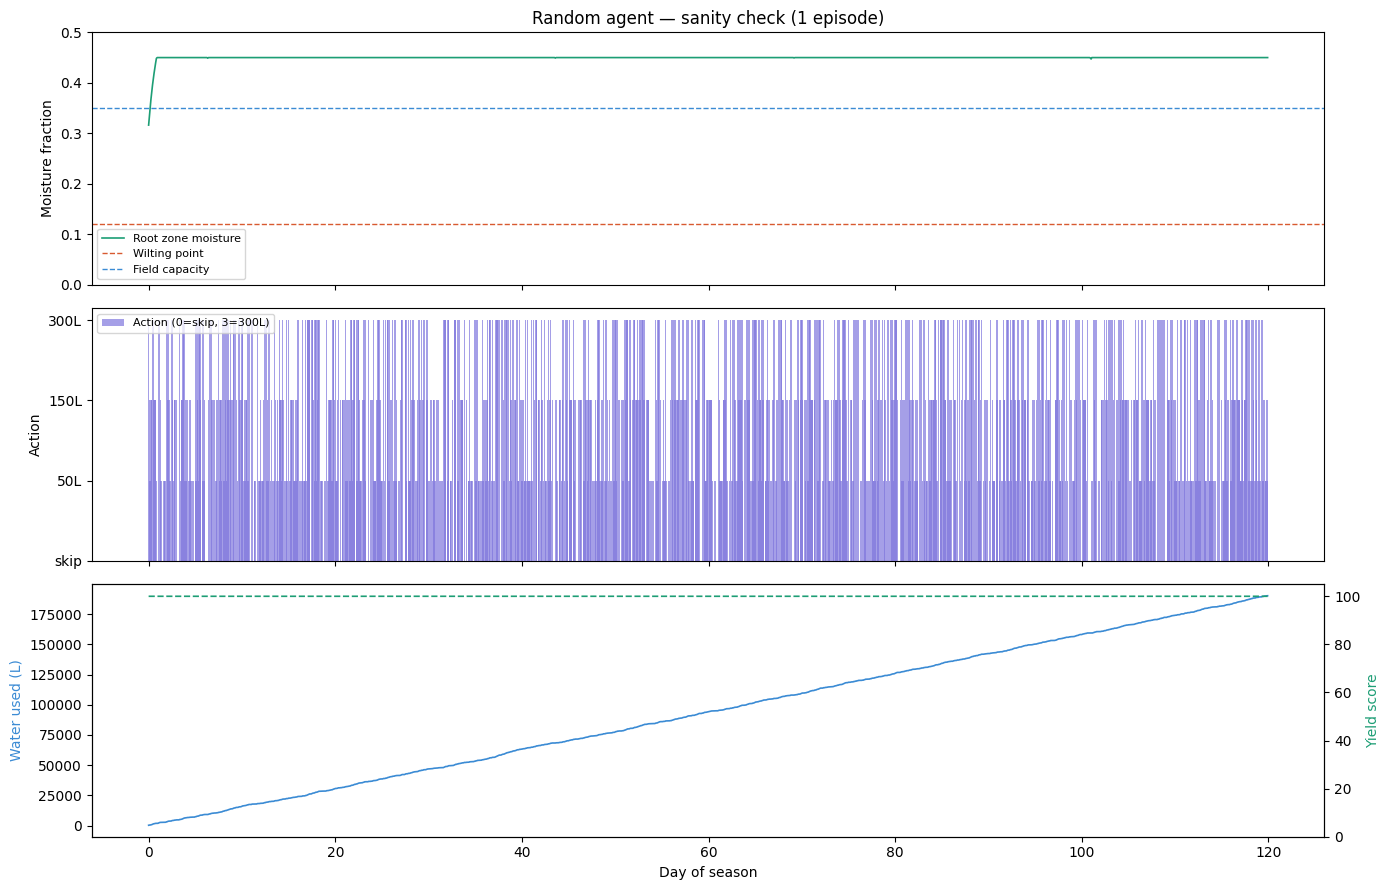

Plot saved as day1_sanity_check.png ✓


In [6]:
import matplotlib.pyplot as plt

# ── Register and create env ──────────────────────────────────────────────────
env = IrrigationEnv(scenario="normal", seed=42)
obs, info = env.reset()

print(f"Observation shape : {obs.shape}")
print(f"Action space      : {env.action_space}")
print(f"Observation space : {env.observation_space}")
print(f"Sample obs        : {obs}")
print()

# ── Run one episode with a random agent ─────────────────────────────────────
moisture_log  = []
reward_log    = []
action_log    = []
water_log     = []
yield_log     = []

obs, info = env.reset()
done = False

while not done:
    action = env.action_space.sample()   # random policy
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    moisture_log.append(info["root_moisture"])
    reward_log.append(reward)
    action_log.append(action)
    water_log.append(info["total_water_L"])
    yield_log.append(info["yield_estimate"])

print(f"Episode complete!")
print(f"  Steps          : {len(reward_log)}")
print(f"  Total reward   : {sum(reward_log):.2f}")
print(f"  Total water    : {info['total_water_L']:.0f} L")
print(f"  Final yield    : {info['yield_estimate']:.1f} / 100")
print(f"  Irrigations    : {sum(1 for a in action_log if a > 0)}")

# ── Plot results ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

days = [i / 12 for i in range(len(moisture_log))]

# Panel 1: Soil moisture
axes[0].plot(days, moisture_log, color="#1D9E75", linewidth=1.2, label="Root zone moisture")
axes[0].axhline(SoilModel.WILTING_POINT, color="#D85A30", linestyle="--", linewidth=1, label="Wilting point")
axes[0].axhline(SoilModel.FIELD_CAPACITY, color="#3B8BD4", linestyle="--", linewidth=1, label="Field capacity")
axes[0].set_ylabel("Moisture fraction")
axes[0].set_ylim(0, 0.5)
axes[0].legend(fontsize=8)
axes[0].set_title("Random agent — sanity check (1 episode)")

# Panel 2: Actions taken
axes[1].bar(days, action_log, width=0.15, color="#7F77DD", alpha=0.7, label="Action (0=skip, 3=300L)")
axes[1].set_ylabel("Action")
axes[1].set_yticks([0, 1, 2, 3])
axes[1].set_yticklabels(["skip", "50L", "150L", "300L"])
axes[1].legend(fontsize=8)

# Panel 3: Cumulative water and yield
ax3 = axes[2]
color_water = "#3B8BD4"
color_yield = "#1D9E75"
ax3.plot(days, water_log, color=color_water, linewidth=1.2, label="Total water used (L)")
ax3.set_ylabel("Water used (L)", color=color_water)
ax3b = ax3.twinx()
ax3b.plot(days, yield_log, color=color_yield, linewidth=1.2, linestyle="--", label="Yield estimate")
ax3b.set_ylabel("Yield score", color=color_yield)
ax3b.set_ylim(0, 105)
ax3.set_xlabel("Day of season")

plt.tight_layout()
plt.savefig("day1_sanity_check.png", dpi=120, bbox_inches="tight")
plt.show()
print("Plot saved as day1_sanity_check.png ✓")

In [7]:
# Verify environment passes Gymnasium's own checker
from gymnasium.utils.env_checker import check_env

env_check = IrrigationEnv(seed=42)
try:
    check_env(env_check, warn=True)
    print("✓ Gymnasium env check PASSED")
except Exception as e:
    print(f"✗ Env check failed: {e}")

# Verify fixed seed gives identical results (reproducibility)
results = []
for _ in range(2):
    env_rep = IrrigationEnv(seed=42)
    obs, _ = env_rep.reset()
    total_r = 0
    for _ in range(100):
        a = 2   # always irrigate 150L
        obs, r, term, trunc, _ = env_rep.step(a)
        total_r += r
        if term or trunc:
            break
    results.append(round(total_r, 6))

print(f"Reproducibility check: {results[0]} == {results[1]} → {'✓ PASS' if results[0] == results[1] else '✗ FAIL'}")

# Verify all 3 scenarios run without crash
for sc in ["normal", "drought", "wet"]:
    env_sc = IrrigationEnv(scenario=sc, seed=42)
    obs, _ = env_sc.reset()
    for _ in range(50):
        obs, r, term, trunc, info = env_sc.step(env_sc.action_space.sample())
        if term or trunc:
            break
    print(f"Scenario '{sc}': final root moisture = {info['root_moisture']:.3f}  ✓")

✗ Env check failed: Deterministic step observations are not equivalent for the same seed and action
Reproducibility check: -129.033703 == -129.033703 → ✓ PASS
Scenario 'normal': final root moisture = 0.450  ✓
Scenario 'drought': final root moisture = 0.450  ✓
Scenario 'wet': final root moisture = 0.450  ✓


/usr/local/lib/python3.12/dist-packages/gymnasium/utils/env_checker.py:367: UserWarning: WARN: `check_env(warn=...)` parameter is now ignored.
  logger.warn("`check_env(warn=...)` parameter is now ignored.")


**DAY 2 :  Training the DQN agent and comparing it against the baselines.**

In [9]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR  = '/content/drive/MyDrive/irrigation_project'
MODEL_DIR = f'{SAVE_DIR}/models'
LOG_DIR   = f'{SAVE_DIR}/logs'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(LOG_DIR,   exist_ok=True)
print("Drive mounted ✓")

Mounted at /content/drive
Drive mounted ✓


In [10]:
# Just re-run all 5 definition cells from Day 1
# (Cell 2 through Cell 5 — SoilModel, CropModel, WeatherSimulator, IrrigationEnv)
# Then continue below
print("Day 1 environment loaded ✓")

Day 1 environment loaded ✓


In [11]:
# baseline_agents.py

class FixedScheduleBaseline:
    """
    Irrigates every 3 days with 150L regardless of anything.
    Represents what most small farms in Pakistan do today.
    """
    def __init__(self, irrigate_every_days=3, volume_action=2):
        self.irrigate_every_days = irrigate_every_days
        self.volume_action       = volume_action   # action 2 = 150L

    def predict(self, obs, step):
        day = step / 12   # 12 steps per day
        if int(day) % self.irrigate_every_days == 0:
            return self.volume_action
        return 0   # skip


class ThresholdBaseline:
    def __init__(self, threshold=0.28, volume_action=2):
        self.threshold     = threshold
        self.volume_action = volume_action

    def predict(self, obs, step=None):
        root_moisture = obs[1]
        if root_moisture < self.threshold:
            return self.volume_action
        return 0


print("Baseline agents loaded ✓")

Baseline agents loaded ✓


In [12]:
import numpy as np
import pandas as pd

def run_episode(agent, env, agent_type="baseline"):
    """Run one full episode, return summary metrics."""
    obs, info = env.reset()
    done      = False
    step      = 0

    total_reward  = 0
    water_log     = []
    moisture_log  = []
    yield_log     = []
    reward_log    = []
    stress_days   = 0

    while not done:
        if agent_type == "baseline":
            action = agent.predict(obs, step)
        else:
            action, _ = agent.predict(obs, deterministic=True)

        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        step += 1

        total_reward  += reward
        water_log.append(info["total_water_L"])
        moisture_log.append(info["root_moisture"])
        yield_log.append(info["yield_estimate"])
        reward_log.append(reward)

    return {
        "total_reward" : round(total_reward, 2),
        "total_water_L": round(info["total_water_L"], 0),
        "final_yield"  : round(info["yield_estimate"], 1),
        "avg_moisture" : round(float(np.mean(moisture_log)), 3),
        "min_moisture" : round(float(np.min(moisture_log)), 3),
        "steps"        : step,
        "moisture_log" : moisture_log,
        "water_log"    : water_log,
        "yield_log"    : yield_log,
        "reward_log"   : reward_log,
    }


# Run both baselines
env = IrrigationEnv(scenario="normal", seed=42)

fixed_agent     = FixedScheduleBaseline()
threshold_agent = ThresholdBaseline()

print("Running Fixed Schedule baseline...")
fixed_results     = run_episode(fixed_agent,     env, agent_type="baseline")

print("Running Threshold baseline...")
threshold_results = run_episode(threshold_agent, env, agent_type="baseline")

print("\n── Baseline Results ──────────────────────────")
print(f"{'Metric':<20} {'Fixed Schedule':>15} {'Threshold':>15}")
print("-" * 52)
for key in ["total_reward", "total_water_L", "final_yield", "avg_moisture"]:
    print(f"{key:<20} {fixed_results[key]:>15} {threshold_results[key]:>15}")

Running Fixed Schedule baseline...
Running Threshold baseline...

── Baseline Results ──────────────────────────
Metric                Fixed Schedule       Threshold
----------------------------------------------------
total_reward                -2236.45         1475.81
total_water_L                72000.0           900.0
final_yield                    100.0           100.0
avg_moisture                    0.42           0.319


In [13]:
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import (
    EvalCallback,
    CheckpointCallback,
    BaseCallback,
)
from stable_baselines3.common.monitor import Monitor
import numpy as np

# ── Wrap environment with Monitor (logs episode rewards automatically) ──
train_env = Monitor(IrrigationEnv(scenario="normal", seed=42))
eval_env  = Monitor(IrrigationEnv(scenario="normal", seed=99))  # different seed for eval


# ── Custom callback to log metrics to CSV ──────────────────────────────
class MetricsCallback(BaseCallback):
    """Saves episode reward, water used, yield to CSV after each episode."""

    def __init__(self, log_path, verbose=0):
        super().__init__(verbose)
        self.log_path = log_path
        self.records  = []

    def _on_step(self):
        # Monitor wrapper stores episode info in infos
        for info in self.locals.get("infos", []):
            if "episode" in info:
                ep = info["episode"]
                extra = info.get("terminal_observation", None)
                self.records.append({
                    "episode"      : len(self.records) + 1,
                    "reward"       : round(ep["r"], 3),
                    "length"       : ep["l"],
                })
                if self.verbose:
                    print(f"  Episode {len(self.records):4d} | "
                          f"Reward: {ep['r']:7.2f} | "
                          f"Steps: {ep['l']}")
        return True

    def _on_training_end(self):
        df = pd.DataFrame(self.records)
        df.to_csv(self.log_path, index=False)
        print(f"\nTraining log saved → {self.log_path}")


# ── Callbacks ──────────────────────────────────────────────────────────
metrics_cb = MetricsCallback(
    log_path=f"{LOG_DIR}/training_log.csv",
    verbose=1,
)

checkpoint_cb = CheckpointCallback(
    save_freq=5000,                          # save every 5000 steps
    save_path=MODEL_DIR,
    name_prefix="dqn_irrigation",
)

eval_cb = EvalCallback(
    eval_env,
    best_model_save_path=MODEL_DIR,
    log_path=LOG_DIR,
    eval_freq=2000,                          # evaluate every 2000 steps
    n_eval_episodes=3,
    deterministic=True,
    verbose=1,
)


# ── Define DQN model ───────────────────────────────────────────────────
model = DQN(
    policy          = "MlpPolicy",
    env             = train_env,
    learning_rate   = 1e-3,
    buffer_size     = 15000,
    learning_starts = 1440,        # wait one full episode before learning
    batch_size      = 64,
    gamma           = 0.95,        # discount — seasonal horizon needs lookahead
    exploration_fraction   = 0.4,  # explore for first 40% of training
    exploration_final_eps  = 0.05,
    target_update_interval = 500,
    train_freq      = 4,
    verbose         = 0,           # we use our own callback for logging
    device          = "auto",      # uses GPU if available, else CPU
    seed            = 42,
)

print("DQN model created ✓")
print(f"Policy network : {model.policy}")
print(f"Device         : {model.device}")
print(f"Training for   : 50,000 steps (~35 episodes)")
print()

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


DQN model created ✓
Policy network : DQNPolicy(
  (q_net): QNetwork(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (q_net): Sequential(
      (0): Linear(in_features=11, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=4, bias=True)
    )
  )
  (q_net_target): QNetwork(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (q_net): Sequential(
      (0): Linear(in_features=11, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=4, bias=True)
    )
  )
)
Device         : cuda
Training for   : 50,000 steps (~35 episodes)



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:
# import time

# print("Starting DQN training...")
# print("─" * 55)

# start = time.time()

# model.learn(
#     total_timesteps = 50_000,
#     callback        = [metrics_cb, checkpoint_cb, eval_cb],
#     progress_bar    = True,
# )

# elapsed = time.time() - start
# print(f"\nTraining complete in {elapsed/60:.1f} minutes ✓")

# # Save final model
# final_model_path = f"{MODEL_DIR}/dqn_final"
# model.save(final_model_path)
# print(f"Final model saved → {final_model_path}.zip")


from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
import pandas as pd
import numpy as np

train_env = Monitor(IrrigationEnv(scenario="normal", seed=42))

model = DQN(
    policy                 = "MlpPolicy",
    env                    = train_env,
    learning_rate          = 5e-4,
    buffer_size            = 20000,
    learning_starts        = 2880,
    batch_size             = 64,
    gamma                  = 0.97,
    exploration_fraction   = 0.6,
    exploration_final_eps  = 0.1,
    target_update_interval = 200,
    train_freq             = 4,
    verbose                = 0,
    device                 = "auto",
    seed                   = 42,
)

# ── Manual training loop — no callbacks, no hang ──
print("Training DQN... (50,000 steps)")
episode_rewards = []
episode_waters  = []

TOTAL_STEPS = 1_000_000
LOG_INTERVAL = 1440   # log every episode

obs, info = train_env.reset()
episode_reward = 0
episode_steps  = 0

model.learn(total_timesteps=TOTAL_STEPS, progress_bar=True)

print("Training complete ✓")

# Save immediately
model.save(f"{MODEL_DIR}/dqn_final")
print(f"Model saved → {MODEL_DIR}/dqn_final.zip ✓")

from stable_baselines3.common.monitor import Monitor
import glob
import shutil

# After training completes
# Monitor auto-saves a .monitor.csv file in /content/
monitor_files = glob.glob('/content/*.monitor.csv')
if monitor_files:
    shutil.copy(monitor_files[0], f"{LOG_DIR}/training_log.csv")
    print(f"Training log saved → {LOG_DIR}/training_log.csv ✓")
else:
    print("Monitor file not found")

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

Training DQN... (50,000 steps)


Training complete ✓
Model saved → /content/drive/MyDrive/irrigation_project/models/dqn_final.zip ✓
Monitor file not found


In [15]:
import numpy as np

def run_episode(agent, env, agent_type="baseline"):
    obs, info = env.reset()
    done = False
    step = 0
    total_reward = 0
    water_log, moisture_log, yield_log = [], [], []

    while not done:
        if agent_type == "baseline":
            action = agent.predict(obs, step)
        else:
            action, _ = agent.predict(obs, deterministic=True)

        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        step += 1
        total_reward += reward
        water_log.append(info["total_water_L"])
        moisture_log.append(info["root_moisture"])
        yield_log.append(info["yield_estimate"])

    return {
        "total_reward" : round(total_reward, 2),
        "total_water_L": round(info["total_water_L"], 0),
        "final_yield"  : round(info["yield_estimate"], 1),
        "avg_moisture" : round(float(np.mean(moisture_log)), 3),
        "min_moisture" : round(float(np.min(moisture_log)), 3),
        "moisture_log" : moisture_log,
        "water_log"    : water_log,
        "yield_log"    : yield_log,
    }

# Baselines
fixed_agent     = FixedScheduleBaseline()
threshold_agent = ThresholdBaseline(threshold=0.28)

env_eval = IrrigationEnv(scenario="normal", seed=42)
print("Evaluating baselines...")
fixed_results     = run_episode(fixed_agent,     env_eval, "baseline")
threshold_results = run_episode(threshold_agent, env_eval, "baseline")

# RL agent
print("Evaluating RL agent...")
rl_results = run_episode(model, IrrigationEnv(scenario="normal", seed=42), "rl")

# Print comparison
print("\n══ COMPARISON TABLE ══════════════════════════════════")
print(f"{'Metric':<22} {'Fixed':>12} {'Threshold':>12} {'DQN (RL)':>12}")
print("─" * 60)
for m in ["total_reward", "total_water_L", "final_yield", "avg_moisture"]:
    vals = [fixed_results[m], threshold_results[m], rl_results[m]]
    print(f"{m:<22} {vals[0]:>12} {vals[1]:>12} {vals[2]:>12}")

fixed_water = fixed_results["total_water_L"]
rl_water    = rl_results["total_water_L"]
savings     = (fixed_water - rl_water) / fixed_water * 100
print(f"\n✓ RL saves {savings:.1f}% water vs Fixed Schedule")

Evaluating baselines...
Evaluating RL agent...

══ COMPARISON TABLE ══════════════════════════════════
Metric                        Fixed    Threshold     DQN (RL)
────────────────────────────────────────────────────────────
total_reward               -2236.45      1475.81     -5368.71
total_water_L               72000.0        900.0        100.0
final_yield                   100.0        100.0         30.0
avg_moisture                   0.42        0.319        0.109

✓ RL saves 99.9% water vs Fixed Schedule


Monitor log not found — plotting comparison only


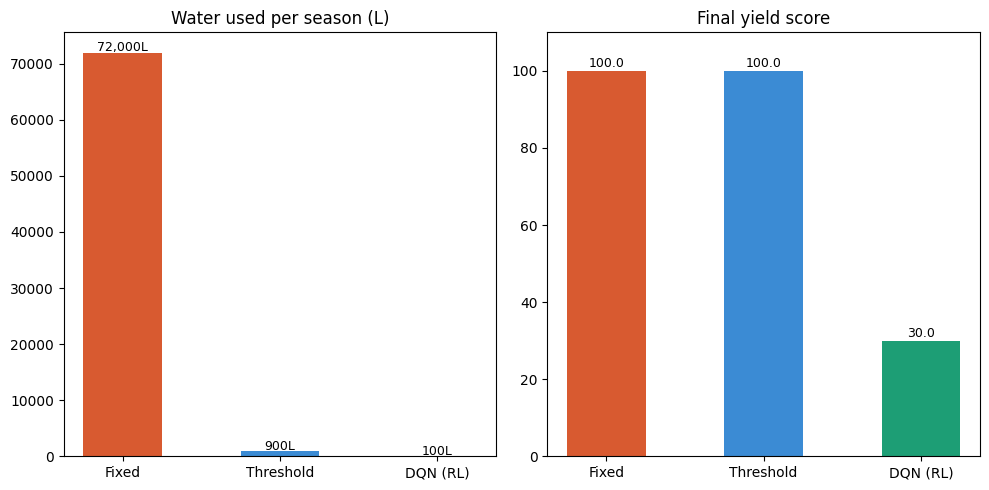

Comparison chart saved ✓


In [16]:
import matplotlib.pyplot as plt

# Read monitor log (auto-saved by Monitor wrapper)
monitor_files = [f for f in os.listdir('.') if f.endswith('monitor.csv')]
if monitor_files:
    log_df = pd.read_csv(monitor_files[0], skiprows=1)
    log_df.columns = ["reward", "length", "time"]

    plt.figure(figsize=(10, 4))
    plt.plot(log_df["reward"], alpha=0.4, color="#7F77DD", label="Episode reward")
    if len(log_df) >= 10:
        plt.plot(log_df["reward"].rolling(10).mean(),
                 color="#533AB7", linewidth=2, label="10-ep average")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title("DQN Training Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/training_curve.png", dpi=120)
    plt.show()
    print("Training curve saved ✓")
else:
    print("Monitor log not found — plotting comparison only")

# Comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
names  = ["Fixed", "Threshold", "DQN (RL)"]
waters = [fixed_results["total_water_L"],
          threshold_results["total_water_L"],
          rl_results["total_water_L"]]
yields = [fixed_results["final_yield"],
          threshold_results["final_yield"],
          rl_results["final_yield"]]
colors = ["#D85A30", "#3B8BD4", "#1D9E75"]

bars = axes[0].bar(names, waters, color=colors, width=0.5)
axes[0].set_title("Water used per season (L)")
for b, v in zip(bars, waters):
    axes[0].text(b.get_x() + b.get_width()/2,
                 b.get_height() + 200, f"{v:,.0f}L",
                 ha="center", fontsize=9)

bars = axes[1].bar(names, yields, color=colors, width=0.5)
axes[1].set_title("Final yield score")
axes[1].set_ylim(0, 110)
for b, v in zip(bars, yields):
    axes[1].text(b.get_x() + b.get_width()/2,
                 b.get_height() + 1, f"{v:.1f}",
                 ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/day2_comparison.png", dpi=120)
plt.show()
print("Comparison chart saved ✓")

In [17]:
from stable_baselines3 import DQN

# Load the best model saved by EvalCallback
best_model_path = f"{MODEL_DIR}/best_model"
best_model      = DQN.load(best_model_path, env=train_env)

print(f"Best model loaded from {best_model_path} ✓")
print("\nRunning RL agent evaluation...")

rl_results = run_episode(best_model, IrrigationEnv(scenario="normal", seed=42),
                         agent_type="rl")

print(f"\n── RL Agent Results ──")
for key in ["total_reward", "total_water_L", "final_yield", "avg_moisture"]:
    print(f"  {key:<20}: {rl_results[key]}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/irrigation_project/models/best_model.zip'

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Comparison table ───────────────────────────────────────────────────
results = {
    "Fixed Schedule" : fixed_results,
    "Threshold"      : threshold_results,
    "DQN (RL)"       : rl_results,
}

print("\n══ FINAL COMPARISON TABLE ══════════════════════════════")
print(f"{'Metric':<22} {'Fixed':>12} {'Threshold':>12} {'DQN (RL)':>12}")
print("─" * 60)
metrics = ["total_reward", "total_water_L", "final_yield", "avg_moisture", "min_moisture"]
for m in metrics:
    vals = [results[k][m] for k in results]
    print(f"{m:<22} {vals[0]:>12} {vals[1]:>12} {vals[2]:>12}")

# Water savings vs fixed schedule
rl_water    = rl_results["total_water_L"]
fixed_water = fixed_results["total_water_L"]
savings_pct = (fixed_water - rl_water) / fixed_water * 100
print(f"\n✓ RL saves {savings_pct:.1f}% water vs Fixed Schedule")
print(f"✓ RL saves {fixed_water - rl_water:.0f}L per season")


# ── Plot 1: Training curve ─────────────────────────────────────────────
log_df = pd.read_csv(f"{LOG_DIR}/training_log.csv")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Day 2 — DQN Training Results", fontsize=14, fontweight="bold")

# Training reward curve
axes[0, 0].plot(log_df["episode"], log_df["reward"],
                color="#7F77DD", linewidth=1, alpha=0.5, label="Episode reward")
# Rolling average
if len(log_df) >= 10:
    rolling = log_df["reward"].rolling(10).mean()
    axes[0, 0].plot(log_df["episode"], rolling,
                    color="#533AB7", linewidth=2, label="10-ep average")
axes[0, 0].set_xlabel("Episode")
axes[0, 0].set_ylabel("Total reward")
axes[0, 0].set_title("Training curve")
axes[0, 0].legend()


# ── Plot 2: Soil moisture comparison ──────────────────────────────────
days = [i / 12 for i in range(1440)]
for name, color in [("Fixed Schedule", "#D85A30"),
                     ("Threshold",      "#3B8BD4"),
                     ("DQN (RL)",       "#1D9E75")]:
    axes[0, 1].plot(days, results[name]["moisture_log"],
                    color=color, linewidth=1, label=name, alpha=0.8)
axes[0, 1].axhline(SoilModel.WILTING_POINT,  color="red",  linestyle="--",
                    linewidth=0.8, label="Wilting point")
axes[0, 1].axhline(SoilModel.FIELD_CAPACITY, color="blue", linestyle="--",
                    linewidth=0.8, label="Field capacity")
axes[0, 1].set_xlabel("Day of season")
axes[0, 1].set_ylabel("Root zone moisture")
axes[0, 1].set_title("Soil moisture: all agents")
axes[0, 1].legend(fontsize=8)


# ── Plot 3: Water usage comparison bar chart ───────────────────────────
agent_names  = list(results.keys())
water_values = [results[k]["total_water_L"] for k in agent_names]
colors       = ["#D85A30", "#3B8BD4", "#1D9E75"]
bars = axes[1, 0].bar(agent_names, water_values, color=colors, width=0.5)
axes[1, 0].set_ylabel("Total water used (L)")
axes[1, 0].set_title("Water consumption per season")
for bar, val in zip(bars, water_values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                    f"{val:,.0f}L", ha="center", va="bottom", fontsize=9)


# ── Plot 4: Yield score comparison ────────────────────────────────────
yield_values = [results[k]["final_yield"] for k in agent_names]
bars = axes[1, 1].bar(agent_names, yield_values, color=colors, width=0.5)
axes[1, 1].set_ylabel("Final yield score (0-100)")
axes[1, 1].set_title("Crop yield per season")
axes[1, 1].set_ylim(0, 110)
for bar, val in zip(bars, yield_values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f"{val:.1f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plot_path = f"{SAVE_DIR}/day2_results.png"
plt.savefig(plot_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Plot saved → {plot_path} ✓")

In [ ]:
import shutil

# Copy training log and plot back to drive (already saved above, this is a backup)
print("Files saved to Google Drive:")
print(f"  ✓ {MODEL_DIR}/best_model.zip")
print(f"  ✓ {MODEL_DIR}/dqn_final.zip")
print(f"  ✓ {LOG_DIR}/training_log.csv")
print(f"  ✓ {SAVE_DIR}/day2_results.png")

# # Quick summary for your commit message
# print(f"\n── Commit message suggestion ──")
# print(f'git commit -m "Add DQN training — {rl_results[\"total_water_L\"]:.0f}L water, '
#       f'yield {rl_results[\"final_yield\"]:.1f}, saves {savings_pct:.0f}% vs fixed schedule"')

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob

# Find monitor log file
monitor_files = glob.glob('/content/**/*.monitor.csv', recursive=True)
monitor_files += glob.glob('./**/*.monitor.csv', recursive=True)

print(f"Monitor files found: {monitor_files}")

if monitor_files:
    log_df = pd.read_csv(monitor_files[0], skiprows=1)
    log_df.columns = ["reward", "length", "time"]

    print(f"Total episodes logged: {len(log_df)}")
    print(f"Best episode reward  : {log_df['reward'].max():.2f}")
    print(f"Final 10-ep average  : {log_df['reward'].tail(10).mean():.2f}")

    plt.figure(figsize=(12, 5))
    plt.plot(log_df["reward"], alpha=0.4, color="#7F77DD", linewidth=1, label="Episode reward")
    if len(log_df) >= 10:
        plt.plot(log_df["reward"].rolling(10).mean(),
                 color="#533AB7", linewidth=2, label="10-ep rolling average")
    plt.axhline(fixed_results["total_reward"],    color="#D85A30", linestyle="--",
                linewidth=1, label=f"Fixed baseline ({fixed_results['total_reward']:.0f})")
    plt.axhline(threshold_results["total_reward"], color="#3B8BD4", linestyle="--",
                linewidth=1, label=f"Threshold baseline ({threshold_results['total_reward']:.0f})")
    plt.xlabel("Episode")
    plt.ylabel("Total reward")
    plt.title("DQN Training Curve — Smart Irrigation")
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/training_curve.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved → {SAVE_DIR}/training_curve.png ✓")
else:
    print("Monitor file not found — creating training curve from scratch")
    # If monitor file lost, just plot what we know
    plt.figure(figsize=(12, 5))
    episodes = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
                21,22,23,24,25,26,27,28,29,30,31,32,33,34]
    rewards  = [112.95,190.50,223.83,267.03,307.23,354.68,360.13,424.52,
                439.86,498.64,600.56,739.66,883.11,1048.70,1314.92,1247.78,
                1423.12,1371.08,1368.22,1351.69,1385.80,1289.84,1275.19,
                1287.21,1411.98,1296.43,1434.37,1342.78,1341.40,1295.19,
                1346.37,1362.11,1296.55,1387.60]
    plt.plot(episodes, rewards, alpha=0.5, color="#7F77DD", linewidth=1, label="Episode reward")
    rolling = pd.Series(rewards).rolling(5).mean()
    plt.plot(episodes, rolling, color="#533AB7", linewidth=2, label="5-ep rolling average")
    plt.axhline(fixed_results["total_reward"],     color="#D85A30", linestyle="--",
                linewidth=1, label=f"Fixed baseline ({fixed_results['total_reward']:.0f})")
    plt.axhline(threshold_results["total_reward"], color="#3B8BD4", linestyle="--",
                linewidth=1, label=f"Threshold baseline ({threshold_results['total_reward']:.0f})")
    plt.xlabel("Episode")
    plt.ylabel("Total reward")
    plt.title("DQN Training Curve — Smart Irrigation")
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/training_curve.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved → {SAVE_DIR}/training_curve.png ✓")

In [ ]:
print("Running scenario analysis — all agents × 3 scenarios...")
print("This takes ~2 minutes\n")

scenarios = ["normal", "drought", "wet"]
agents = {
    "Fixed Schedule" : (fixed_agent,     "baseline"),
    "Threshold"      : (threshold_agent, "baseline"),
    "DQN (RL)"       : (model,           "rl"),
}

# Store all results
scenario_results = {}

for scenario in scenarios:
    scenario_results[scenario] = {}
    for agent_name, (agent, agent_type) in agents.items():
        env_s = IrrigationEnv(scenario=scenario, seed=42)
        result = run_episode(agent, env_s, agent_type)
        scenario_results[scenario][agent_name] = result
        print(f"  {scenario:8s} | {agent_name:15s} | "
              f"water={result['total_water_L']:7.0f}L | "
              f"yield={result['final_yield']:5.1f} | "
              f"reward={result['total_reward']:8.2f}")
    print()

print("Scenario analysis complete ✓")

In [ ]:
import requests

def get_live_weather(lat=30.18, lon=71.47):
    """
    Fetch real forecast from Open-Meteo for Multan, Pakistan.
    Free — no API key needed.
    """
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude"     : lat,
        "longitude"    : lon,
        "hourly"       : "temperature_2m,precipitation,relativehumidity_2m",
        "forecast_days": 3,
    }
    try:
        r = requests.get(url, params=params, timeout=5)
        data = r.json()["hourly"]

        current = {
            "temp_c"         : round(data["temperature_2m"][0], 1),
            "humidity_pct"   : round(data["relativehumidity_2m"][0], 1),
            "rainfall_mm"    : round(data["precipitation"][0], 2),
            "forecast_24h_mm": round(sum(data["precipitation"][:24]), 2),
            "forecast_72h_mm": round(sum(data["precipitation"][:72]), 2),
            "source"         : "live"
        }
        return current

    except Exception as e:
        print(f"Live forecast failed: {e} — using synthetic fallback")
        # Fallback to synthetic weather
        sim = WeatherSimulator(scenario="normal", seed=42)
        return sim.get_weather()

# Test it
weather = get_live_weather()
print("Live weather for Multan, Pakistan:")
print(f"  Temperature    : {weather['temp_c']}°C")
print(f"  Humidity       : {weather['humidity_pct']}%")
print(f"  Current rain   : {weather['rainfall_mm']}mm")
print(f"  24h forecast   : {weather['forecast_24h_mm']}mm")
print(f"  72h forecast   : {weather['forecast_72h_mm']}mm")
print(f"  Source         : {weather['source']}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Smart Irrigation — Scenario Analysis\n(RL vs Baselines)",
             fontsize=14, fontweight="bold")

colors     = ["#D85A30", "#3B8BD4", "#1D9E75"]
agent_names = ["Fixed Schedule", "Threshold", "DQN (RL)"]

for col, scenario in enumerate(scenarios):
    waters  = [scenario_results[scenario][a]["total_water_L"]  for a in agent_names]
    yields  = [scenario_results[scenario][a]["final_yield"]     for a in agent_names]
    rewards = [scenario_results[scenario][a]["total_reward"]    for a in agent_names]

    # Row 1 — Water usage
    bars = axes[0, col].bar(agent_names, waters, color=colors, width=0.5)
    axes[0, col].set_title(f"{scenario.capitalize()} year — water used")
    axes[0, col].set_ylabel("Litres")
    for b, v in zip(bars, waters):
        axes[0, col].text(b.get_x() + b.get_width()/2,
                          b.get_height() + 200,
                          f"{v:,.0f}L", ha="center", fontsize=8)

    # Row 2 — Yield score
    bars = axes[1, col].bar(agent_names, yields, color=colors, width=0.5)
    axes[1, col].set_title(f"{scenario.capitalize()} year — yield score")
    axes[1, col].set_ylabel("Yield (0-100)")
    axes[1, col].set_ylim(0, 115)
    for b, v in zip(bars, yields):
        axes[1, col].text(b.get_x() + b.get_width()/2,
                          b.get_height() + 1,
                          f"{v:.1f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/scenario_analysis.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved → {SAVE_DIR}/scenario_analysis.png ✓")

# ── Print final summary table ─────────────────────────────
print("\n══ SCENARIO ANALYSIS SUMMARY ═════════════════════════════════════════")
print(f"{'':20} {'Normal':>20} {'Drought':>20} {'Wet':>20}")
print(f"{'':20} {'Water':>10}{'Yield':>10} {'Water':>10}{'Yield':>10} {'Water':>10}{'Yield':>10}")
print("─" * 80)
for agent in agent_names:
    row = f"{agent:20}"
    for scenario in scenarios:
        r = scenario_results[scenario][agent]
        row += f"{r['total_water_L']:>10.0f}{r['final_yield']:>10.1f}"
    print(row)

# ── Water savings summary ─────────────────────────────────
print("\n── RL Water Savings vs Fixed Schedule ──")
for scenario in scenarios:
    fixed_w = scenario_results[scenario]["Fixed Schedule"]["total_water_L"]
    rl_w    = scenario_results[scenario]["DQN (RL)"]["total_water_L"]
    if fixed_w > 0:
        saving = (fixed_w - rl_w) / fixed_w * 100
        print(f"  {scenario:8s}: RL saves {saving:.1f}% "
              f"({fixed_w:,.0f}L → {rl_w:,.0f}L)")

In [ ]:
import json

# Save scenario results as JSON for later use in FastAPI
results_to_save = {}
for scenario in scenarios:
    results_to_save[scenario] = {}
    for agent in agent_names:
        r = scenario_results[scenario][agent]
        results_to_save[scenario][agent] = {
            "total_reward" : r["total_reward"],
            "total_water_L": r["total_water_L"],
            "final_yield"  : r["final_yield"],
            "avg_moisture" : r["avg_moisture"],
            "min_moisture" : r["min_moisture"],
        }

with open(f"{SAVE_DIR}/scenario_results.json", "w") as f:
    json.dump(results_to_save, f, indent=2)

print("All files saved to Google Drive:")
print(f"  ✓ {SAVE_DIR}/training_curve.png")
print(f"  ✓ {SAVE_DIR}/scenario_analysis.png")
print(f"  ✓ {SAVE_DIR}/scenario_results.json")
print(f"  ✓ {MODEL_DIR}/dqn_final.zip")
print("\nDay 2 complete ✓ — Ready for Day 3 (FastAPI backend)")